In [20]:
import sys
import os
import numpy as np

# Tell the notebook to look at the main project folder
sys.path.append(os.path.abspath(os.path.join('..')))

from multi_car_racing.multi_car_racing import MultiCarRacing
from agents.control_pid import PIDAgent

In [21]:
import sys
sys.path.append('..')

from scripts.optimal import compute_optimal_line
from agents.control_pid import PIDAgent

In [22]:
# 1. Start the simulation
env = MultiCarRacing(num_agents=1, render_mode="human")
obs, info = env.reset()

# 2. Build the PID Agent
# It needs the track data from the env to compute the optimal line!
agent = PIDAgent(env.unwrapped.track)

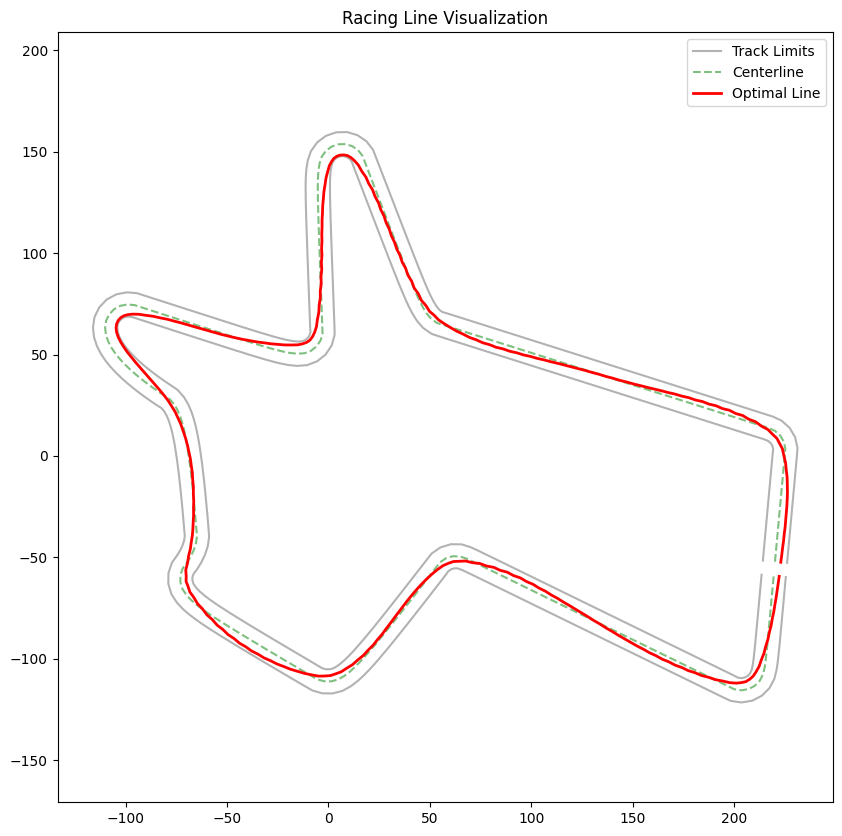

In [23]:
import matplotlib.pyplot as plt

# 1. Extract the centerline (from the env)
track_data = env.unwrapped.track
centerline = np.array([(p[2], p[3]) for p in track_data])

# 2. Access the optimal path (from your agent)
opt_path = self_path = agent.path

# 3. Calculate Boundaries for context
# We use the same normal logic from your scripts/optimal.py
tangents = np.roll(centerline, -1, axis=0) - np.roll(centerline, 1, axis=0)
normals = np.array([-tangents[:, 1], tangents[:, 0]]).T
normals /= np.linalg.norm(normals, axis=1)[:, np.newaxis]

inner_limit = centerline - (normals * 6.0)
outer_limit = centerline + (normals * 6.0)

# 4. Plot
plt.figure(figsize=(10, 10))
plt.plot(inner_limit[:, 0], inner_limit[:, 1], 'k-', alpha=0.3, label="Track Limits")
plt.plot(outer_limit[:, 0], outer_limit[:, 1], 'k-', alpha=0.3)
plt.plot(centerline[:, 0], centerline[:, 1], 'g--', alpha=0.5, label="Centerline")
plt.plot(opt_path[:, 0], opt_path[:, 1], 'r-', linewidth=2, label="Optimal Line")

plt.axis('equal')
plt.legend()
plt.title("Racing Line Visualization")
plt.show()

In [24]:
done = False
while not done:
    car = env.unwrapped.cars[0] 
    
    x, y = car.hull.position
    theta = car.hull.angle
    vx, vy = car.hull.linearVelocity
    speed = np.sqrt(vx**2 + vy**2)

    # 2. GET ACTION FROM PID
    action = agent.step(x, y, theta, speed)

    # 3. STEP THE ENVIRONMENT
    obs, reward, terminated, truncated, info = env.step(action)
    
    # 4. RENDER
    env.render()

    done = terminated or truncated

env.close()

NameError: name 'target_angle' is not defined